# 3. Model Training

## Summary
Trains DronePrint's **LSTM classifier** (Fig. 8 / Section 4.5.1) - the exact same architecture is
reused, unmodified, for all three stages of the cascade:

| Classifier | Task | Classes |
|---|---|---|
| **X** | Drone detection | `non_drone` / `drone` (+ open-set handling, see §3.5) |
| **Y** | Make identification | `DJI`, `Parrot`, ... (whichever makes are present) |
| **Z_<MAKE>** | Model identification within a make | e.g. `Spark`, `MavicPro`, ... |

### Architecture (Fig. 8)
Input `(10, 40)` &rarr; 2 stacked LSTM layers (hidden size 32) &rarr; Dense (fully-connected) &rarr;
Softmax.

### Training recipe (Section 4.5.1)
- **Optimizer**: Adam, learning rate **1e-4**
- **Epochs**: up to **500**
- **Model selection**: keep the checkpoint with the **lowest validation loss** (we still allow
  early stopping with a generous patience purely to save compute - the *selection* criterion itself
  is the paper's, not the stopping criterion)
- **Inference**: average the softmax probabilities of **3 consecutive windows** (&asymp;6s) and
  take the arg-max (implemented in notebook 04)

### Open-set drone detection (Section 4.5.2)
Classifier X is trained **twice**, with two different open-set strategies, exactly like the paper
compares them:
1. **Background class** - a closed-set binary classifier trained with non-drone sounds (DS2) as an
   explicit negative class.
2. **Modified OpenMax** - a closed-set classifier trained on *drone classes only* (no non-drone
   data needed at training time), with a class-wise Weibull-calibrated "unknown" rejection layer
   added at inference time.

### Imports

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
os.makedirs("plots", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.21.0
GPU available: False


## 3.1  The DronePrint LSTM (Fig. 8)

One architecture, reused for every classifier in the cascade. `n_classes` is the only thing that
changes between X / Y / Z.

In [2]:
HIDDEN_SIZE = 32        # Fig. 8: "Hidden Unit Size = 32"
N_TIMESTEPS = 10        # Fig. 8: 10 LSTM steps (10 x 200ms frames = 2s)
N_MFCC = 40              # Fig. 8: "40 MFCC features"
LEARNING_RATE = 1e-4     # Section 4.5.1: "Adam optimizer with a learning rate of 0.0001"
MAX_EPOCHS = 500         # Section 4.5.1: "trained ... for 500 epochs"


def build_droneprint_lstm(n_classes: int, input_shape=(N_TIMESTEPS, N_MFCC), hidden_size=HIDDEN_SIZE,
                           name="droneprint_lstm"):
    """
    DronePrint's classifier (Fig. 8): 2 stacked LSTM layers -> Dense -> Softmax.
    Used identically for Classifier X (n_classes=2), Y (n_classes=#makes),
    and each Z_<MAKE> (n_classes=#models in that make).
    """
    inputs = keras.Input(shape=input_shape, name="mfcc_input")
    x = layers.LSTM(hidden_size, return_sequences=True, name="lstm_1")(inputs)
    x = layers.LSTM(hidden_size, return_sequences=False, name="lstm_2")(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="softmax_prediction")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# Quick sanity check of the architecture
_sanity_model = build_droneprint_lstm(n_classes=2)
_sanity_model.summary()
print(f"\nTotal parameters: {_sanity_model.count_params():,}")
del _sanity_model

Model: "droneprint_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 10, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 32)         │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_prediction (Dense)      │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,730 (69.26 KB)

 Trainable params: 17,730 (69.26 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 17,730


## 3.2  Generic training helper

Trains one LSTM classifier, with `ModelCheckpoint(monitor="val_loss", save_best_only=True)` as the
model-selection rule the paper describes, plus an early-stopping safety net so we don't always have
to wait for the full 500 epochs. Class weights are computed automatically to handle any residual
imbalance (after the balancing already done in notebook 02).

In [3]:
def train_classifier(name, X_train, y_train, X_val, y_val, n_classes,
                      max_epochs=MAX_EPOCHS, batch_size=32, patience=30):
    """Train one DronePrint-LSTM classifier and return (model, history_df)."""
    print(f"\n{'='*60}\nTraining classifier: {name}   "
          f"(n_classes={n_classes}, train={X_train.shape}, val={X_val.shape})\n{'='*60}")

    model = build_droneprint_lstm(n_classes=n_classes)

    classes = np.unique(y_train)
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weight = dict(zip(classes.astype(int), weights))
    print("Class weights:", class_weight)

    ckpt_path = f"models/{name}.keras"
    log_path = f"models/{name}_training_log.csv"
    cb_list = [
        callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=0),
        callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=patience // 2,
                                     min_lr=1e-7, verbose=0),
        callbacks.CSVLogger(log_path),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=cb_list,
        verbose=2,
    )

    # Reload the best checkpoint explicitly (paper: "select the trained model having the lowest
    # validation loss"), in case EarlyStopping's restore_best_weights and the checkpoint disagree.
    best_model = keras.models.load_model(ckpt_path)
    return best_model, history

## 3.3  Classifier X - drone detection (background-class method)

The simplest, fully closed-set method: train directly on `drone` vs `non_drone` windows.

In [4]:
X_train = np.load("X_detect_train.npy")
y_train = np.load("y_detect_train.npy")
X_val   = np.load("X_detect_val.npy")
y_val   = np.load("y_detect_val.npy")
X_test  = np.load("X_detect_test.npy")
y_test  = np.load("y_detect_test.npy")

print(f"X_train {X_train.shape}  X_val {X_val.shape}  X_test {X_test.shape}")

model_X_bg, history_X_bg = train_classifier(
    "classifier_X_background", X_train, y_train, X_val, y_val, n_classes=2)

val_loss, val_acc = model_X_bg.evaluate(X_val, y_val, verbose=0)
print(f"\nClassifier X (background class) - val accuracy: {val_acc*100:.2f}%  val loss: {val_loss:.4f}")

X_train (3549, 10, 40)  X_val (1680, 10, 40)  X_test (98, 10, 40)

Training classifier: classifier_X_background   (n_classes=2, train=(3549, 10, 40), val=(1680, 10, 40))
Class weights: {np.int64(0): np.float64(0.6259259259259259), np.int64(1): np.float64(2.485294117647059)}
Epoch 1/500
111/111 - 3s - 23ms/step - accuracy: 0.4122 - loss: 0.6897 - val_accuracy: 0.8970 - val_loss: 0.6681 - learning_rate: 1.0000e-04
Epoch 2/500
111/111 - 1s - 5ms/step - accuracy: 0.9335 - loss: 0.5941 - val_accuracy: 0.9881 - val_loss: 0.4694 - learning_rate: 1.0000e-04
Epoch 3/500
111/111 - 1s - 5ms/step - accuracy: 0.9915 - loss: 0.2389 - val_accuracy: 0.9952 - val_loss: 0.0920 - learning_rate: 1.0000e-04
Epoch 4/500
111/111 - 1s - 5ms/step - accuracy: 0.9955 - loss: 0.0477 - val_accuracy: 0.9952 - val_loss: 0.0313 - learning_rate: 1.0000e-04
Epoch 5/500
111/111 - 1s - 5ms/step - accuracy: 0.9969 - loss: 0.0199 - val_accuracy: 0.9988 - val_loss: 0.0149 - learning_rate: 1.0000e-04
Epoch 6/500
111/111 - 1s

## 3.4  Training curves - Classifier X (background class)

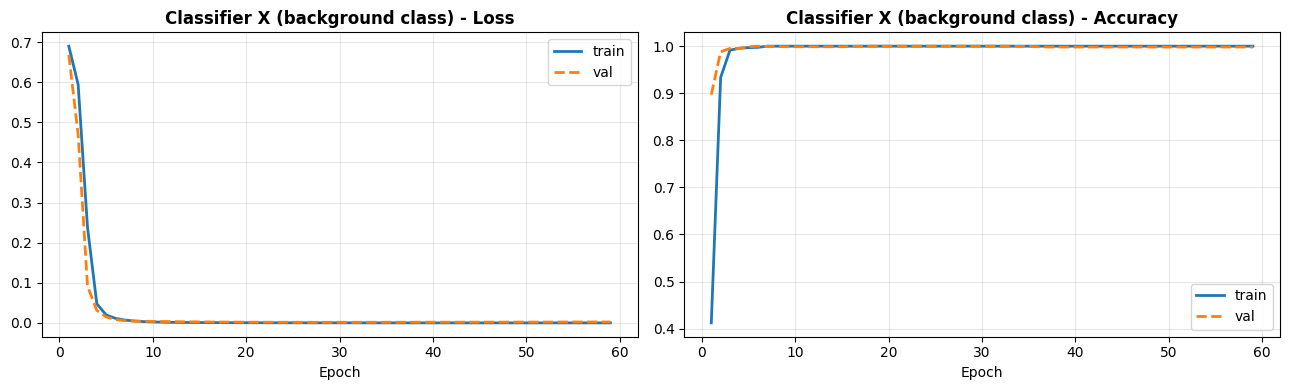

In [5]:
log_bg = pd.read_csv("models/classifier_X_background_training_log.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes, ["loss", "accuracy"], ["Loss", "Accuracy"]):
    ax.plot(log_bg["epoch"] + 1, log_bg[col], label="train", linewidth=2)
    ax.plot(log_bg["epoch"] + 1, log_bg[f"val_{col}"], label="val", linewidth=2, linestyle="--")
    ax.set_title(f"Classifier X (background class) - {title}", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/classifier_X_background_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.5  Classifier X - drone detection (modified OpenMax method)

Section 4.5.2: trains a **closed-set, drone-classes-only** classifier (no non-drone data needed at
training time), then calibrates a class-wise Weibull "unknown" rejection model on top of its
penultimate-layer activations. This is the "Modified OpenMax" from the paper: per-class thresholds
instead of one single global threshold, on top of the original OpenMax algorithm (Bendale & Boult,
2016).

In [6]:
# OpenMax needs a *closed-set, drone-only* classifier (no background class) that covers
# EVERY known drone (make, model) pair - not just the makes that happen to have a Z classifier.
#
# BUGFIX (vs. the previous version of this cell): the earlier version used *only* the Z_<MAKE>
# .npy files as the closed set whenever at least one existed. With your current data that meant
# the closed set was built from Z_DJI alone (4 DJI models) and Parrot was silently dropped
# entirely - so every Parrot test window had no matching class to be recognised as, and OpenMax
# rejected it as "not a drone" by default. That's almost certainly why OpenMax scored only ~54%
# while the background-class method scored ~96% on the same test set: half the drone makes were
# invisible to OpenMax's closed set.
#
# Fixed approach: for every make in make_label_encoder.json, use its dedicated Z_<MAKE> dataset
# (one class per model) if it exists; otherwise fall back to that make's own make-level windows
# from X_make_*.npy as a single class (a make with only one model IS that one model).
import glob

make_classes_list = json.load(open("make_label_encoder.json"))["classes"]
X_make_train_all = np.load("X_make_train.npy"); y_make_train_all = np.load("y_make_train.npy")
X_make_val_all   = np.load("X_make_val.npy");   y_make_val_all   = np.load("y_make_val.npy")

openmax_classes = []     # list of "MAKE::MODEL" strings, index = global class id
X_om_train_list, y_om_train_list = [], []
X_om_val_list, y_om_val_list = [], []

for make_idx, make_name in enumerate(make_classes_list):
    z_train_path = f"X_model_{make_name}_train.npy"
    if os.path.exists(z_train_path):
        # Multi-model make -> one OpenMax class per model, via its dedicated Z_<MAKE> dataset.
        enc = json.load(open(f"model_label_encoder_{make_name}.json"))["classes"]
        offset = len(openmax_classes)
        openmax_classes.extend([f"{make_name}::{m}" for m in enc])

        Xtr = np.load(z_train_path); ytr = np.load(f"y_model_{make_name}_train.npy")
        Xv  = np.load(f"X_model_{make_name}_val.npy");   yv  = np.load(f"y_model_{make_name}_val.npy")
        X_om_train_list.append(Xtr); y_om_train_list.append(ytr + offset)
        X_om_val_list.append(Xv);    y_om_val_list.append(yv + offset)
    else:
        # Single-model make -> treat the whole make as one OpenMax class.
        offset = len(openmax_classes)
        openmax_classes.append(f"{make_name}::(single model)")
        mask_tr = (y_make_train_all == make_idx)
        mask_v  = (y_make_val_all == make_idx)
        X_om_train_list.append(X_make_train_all[mask_tr]); y_om_train_list.append(np.full(mask_tr.sum(), offset))
        X_om_val_list.append(X_make_val_all[mask_v]);       y_om_val_list.append(np.full(mask_v.sum(), offset))

X_om_train = np.concatenate(X_om_train_list); y_om_train = np.concatenate(y_om_train_list)
X_om_val   = np.concatenate(X_om_val_list);   y_om_val   = np.concatenate(y_om_val_list)

print(f"OpenMax closed-set classes ({len(openmax_classes)}): {openmax_classes}")
print(f"X_om_train {X_om_train.shape}  X_om_val {X_om_val.shape}")

model_X_om, history_X_om = train_classifier(
    "classifier_X_openmax_closed_set", X_om_train, y_om_train, X_om_val, y_om_val,
    n_classes=len(openmax_classes))

OpenMax closed-set classes (5): ['DJI::Matrice100', 'DJI::MavicPro', 'DJI::Phantom4Pro', 'DJI::Spark', 'Parrot::(single model)']
X_om_train (1785, 10, 40)  X_om_val (840, 10, 40)

Training classifier: classifier_X_openmax_closed_set   (n_classes=5, train=(1785, 10, 40), val=(840, 10, 40))
Class weights: {np.int64(0): np.float64(1.2142857142857142), np.int64(1): np.float64(1.2142857142857142), np.int64(2): np.float64(1.2142857142857142), np.int64(3): np.float64(1.2142857142857142), np.int64(4): np.float64(0.5862068965517241)}
Epoch 1/500
56/56 - 2s - 37ms/step - accuracy: 0.2090 - loss: 1.5967 - val_accuracy: 0.1940 - val_loss: 1.5942 - learning_rate: 1.0000e-04
Epoch 2/500
56/56 - 0s - 6ms/step - accuracy: 0.3221 - loss: 1.5593 - val_accuracy: 0.3119 - val_loss: 1.5506 - learning_rate: 1.0000e-04
Epoch 3/500
56/56 - 0s - 5ms/step - accuracy: 0.4415 - loss: 1.4989 - val_accuracy: 0.4321 - val_loss: 1.4665 - learning_rate: 1.0000e-04
Epoch 4/500
56/56 - 0s - 5ms/step - accuracy: 0.6123 -

### 3.5.1  OpenMax calibration

A compact, dependency-free re-implementation of OpenMax (Bendale & Boult, CVPR 2016), modified per
DronePrint Section 4.5.2 with **per-class thresholds** instead of one global threshold:

1. For every known class, collect the penultimate-layer activation vectors of its *correctly
   classified* training samples.
2. Compute each class's Mean Activation Vector (MAV).
3. Fit a Weibull distribution to the largest &eta; Euclidean distances from the MAV (the "tail" -
   Extreme Value Theory says the tail of correctly-classified-sample distances is Weibull-shaped).
4. At inference: compute the new sample's activation vector, get its Weibull CDF distance score per
   class, revise (shrink) the top-&alpha; logits accordingly and route the removed probability mass
   into a new "unknown" logit, then re-softmax.
5. Tune one **acceptance threshold per known class** on the validation set.

In [7]:
from scipy.stats import weibull_min

PENULTIMATE_LAYER_NAME = "lstm_2"   # output of the 2nd LSTM layer = the penultimate (pre-softmax) features


def get_activation_extractor(model, layer_name=PENULTIMATE_LAYER_NAME):
    return keras.Model(model.input, model.get_layer(layer_name).output)


def fit_openmax_weibull(model, X_train, y_train, n_classes, tail_size=20):
    """Fit one Weibull tail model per class on correctly-classified training activations."""
    extractor = get_activation_extractor(model)
    activations = extractor.predict(X_train, batch_size=128, verbose=0)
    preds = model.predict(X_train, batch_size=128, verbose=0).argmax(axis=1)

    weibull_params = {}   # class -> (mav, shape_c, loc, scale)
    for c in range(n_classes):
        correct_mask = (y_train == c) & (preds == c)
        acts_c = activations[correct_mask]
        if len(acts_c) < max(tail_size, 3):
            print(f"  [warn] class {c}: only {len(acts_c)} correctly-classified training samples "
                  f"(<{tail_size}) - Weibull fit may be unstable.")
        if len(acts_c) == 0:
            weibull_params[c] = None
            continue
        mav = acts_c.mean(axis=0)
        dists = np.linalg.norm(acts_c - mav, axis=1)
        tail = np.sort(dists)[-min(tail_size, len(dists)):]
        try:
            shape_c, loc, scale = weibull_min.fit(tail, floc=0)
        except Exception:
            shape_c, loc, scale = 1.0, 0.0, max(tail.mean(), 1e-6)
        weibull_params[c] = (mav, shape_c, loc, scale)
    return weibull_params, extractor


def openmax_recalibrate(logits, activation, weibull_params, n_classes, alpha=None):
    """
    Revise raw (pre-softmax) `logits` for one sample using its penultimate `activation` vector.
    Returns a probability vector of length n_classes+1 (last entry = 'unknown').
    """
    if alpha is None:
        alpha = n_classes  # revise all known classes, as in the original OpenMax paper

    ranked = np.argsort(-logits)[:alpha]
    revised = logits.copy()
    unknown_logit = 0.0
    for rank, c in enumerate(ranked):
        params = weibull_params.get(c)
        if params is None:
            continue
        mav, shape_c, loc, scale = params
        dist = np.linalg.norm(activation - mav)
        w_score = weibull_min.cdf(dist, shape_c, loc=loc, scale=scale)
        omega = ((alpha - rank) / alpha) * w_score   # linear rank-weighting, as in the OpenMax paper
        revised[c] = logits[c] * (1 - omega)
        unknown_logit += logits[c] * omega

    full_logits = np.append(revised, unknown_logit)
    exp_l = np.exp(full_logits - full_logits.max())
    probs = exp_l / exp_l.sum()
    return probs   # length n_classes + 1


print("OpenMax helper functions ready.")

OpenMax helper functions ready.


In [8]:
weibull_params, activation_extractor = fit_openmax_weibull(
    model_X_om, X_om_train, y_om_train, n_classes=len(openmax_classes), tail_size=20)

# Save Weibull params (numpy floats -> plain floats so json can serialise them)
weibull_serializable = {
    str(c): (None if v is None else {
        "mav": v[0].tolist(), "shape": float(v[1]), "loc": float(v[2]), "scale": float(v[3])
    })
    for c, v in weibull_params.items()
}
with open("models/openmax_weibull_params.json", "w") as f:
    json.dump({"classes": openmax_classes, "params": weibull_serializable}, f)
print(f"Fitted Weibull tails for {len(weibull_params)} classes.")

Fitted Weibull tails for 5 classes.


### 3.5.2  Per-class threshold tuning (Section 4.5.2)

> *"we assign a separate threshold value for each known class"*

For every known class we sweep a threshold on the OpenMax-revised "is this really class c, or is it
unknown?" score, using the validation set (drone windows of that class = positive, everything else
in the validation set = negative-for-this-class), and keep the threshold that maximises F1 for that
class.

In [9]:
def openmax_predict_batch(model, extractor, weibull_params, X, n_classes):
    # The model's final Dense layer already applies softmax (no raw logits available), so we
    # approximate logits via log of the softmax probabilities (monotonic, rank-preserving stand-in).
    probs_softmax = model.predict(X, batch_size=128, verbose=0)
    pseudo_logits = np.log(np.clip(probs_softmax, 1e-8, 1.0))
    activations = extractor.predict(X, batch_size=128, verbose=0)

    out = np.zeros((len(X), n_classes + 1))
    for i in range(len(X)):
        out[i] = openmax_recalibrate(pseudo_logits[i], activations[i], weibull_params, n_classes)
    return out  # (N, n_classes+1), last column = P(unknown)


def openmax_decide(probs, thresholds_by_class, classes):
    """
    Correct OpenMax decision rule (Section 4.5.2): take the predicted class as the arg-max over
    ALL n_classes+1 entries (including the 'unknown' bucket). If 'unknown' wins, reject outright.
    Otherwise, the predicted KNOWN class must still clear *its own* threshold to be accepted -
    this is NOT "does any class clear its own threshold" (that was the bug in the previous version
    of this notebook: with several moderate per-class thresholds, almost every input - drone or
    not - had at least one class edge over its bar, so nearly everything got flagged 'drone').
    """
    n_classes = len(classes)
    predicted_idx = probs.argmax(axis=1)               # 0..n_classes (n_classes == 'unknown')
    is_known = predicted_idx < n_classes
    thresh_per_row = np.array([thresholds_by_class[classes[c]] if c < n_classes else np.inf
                                for c in predicted_idx])
    prob_of_predicted = probs[np.arange(len(probs)), predicted_idx]
    accepted = is_known & (prob_of_predicted >= thresh_per_row)
    predicted_class = np.where(accepted, predicted_idx, -1)   # -1 = rejected / unknown
    return accepted, predicted_class


# BUGFIX: the previous version of this cell tuned thresholds using ONLY drone-class validation
# windows (X_om_val) - it never saw what a genuine non-drone sound's OpenMax output looks like.
# Combined with the old "any class clears its threshold" decision rule, that meant the tuned
# thresholds had no way to learn to reject non-drone audio at all. We now pull in the non-drone
# validation windows from Classifier X's own validation split (DS2 background sounds) as explicit
# negatives, and tune thresholds against the *argmax-gated* decision rule above (the one actually
# used at inference time), not an isolated per-class F1 that ignores which class was predicted.
X_detect_val_full = np.load("X_detect_val.npy")
y_detect_val_full = np.load("y_detect_val.npy")
X_nondrone_val = X_detect_val_full[y_detect_val_full == 0]
print(f"Non-drone validation windows available for threshold tuning: {X_nondrone_val.shape}")

probs_val_drone = openmax_predict_batch(model_X_om, activation_extractor, weibull_params,
                                         X_om_val, n_classes=len(openmax_classes))
probs_val_nondrone = openmax_predict_batch(model_X_om, activation_extractor, weibull_params,
                                            X_nondrone_val, n_classes=len(openmax_classes))

val_om_probs_full = np.concatenate([probs_val_drone, probs_val_nondrone])
# Sentinel label -1 for "this is truly not any known drone class" (genuine non-drone audio).
val_true_full = np.concatenate([y_om_val, np.full(len(X_nondrone_val), -1)])

class_thresholds = {}
thresholds_grid = np.linspace(0.05, 0.95, 37)
predicted_idx_full = val_om_probs_full.argmax(axis=1)

for c in range(len(openmax_classes)):
    is_class_c = (val_true_full == c)
    predicted_as_c = (predicted_idx_full == c)
    p_c = val_om_probs_full[:, c]
    best_t, best_f1 = 0.5, -1
    for t in thresholds_grid:
        accepted_as_c = predicted_as_c & (p_c >= t)
        tp = np.sum(accepted_as_c & is_class_c)
        fp = np.sum(accepted_as_c & ~is_class_c)
        fn = np.sum(~accepted_as_c & is_class_c)
        f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        if f1 > best_f1:
            best_f1, best_t = f1, t
    class_thresholds[openmax_classes[c]] = float(best_t)
    print(f"  {openmax_classes[c]:>24s}  threshold={best_t:.2f}  val F1={best_f1:.3f}")

# Sanity check: with the fixed decision rule, how many of the non-drone validation windows now
# get correctly rejected as unknown?
_, pred_class_nondrone = openmax_decide(probs_val_nondrone, class_thresholds, openmax_classes)
rejection_rate = float((pred_class_nondrone == -1).mean())
print(f"\nNon-drone validation windows correctly rejected as 'unknown': {rejection_rate*100:.1f}%")

with open("models/openmax_class_thresholds.json", "w") as f:
    json.dump(class_thresholds, f, indent=2)

Non-drone validation windows available for threshold tuning: (945, 10, 40)
           DJI::Matrice100  threshold=0.72  val F1=0.558
             DJI::MavicPro  threshold=0.70  val F1=0.910
          DJI::Phantom4Pro  threshold=0.70  val F1=0.966
                DJI::Spark  threshold=0.47  val F1=0.990
    Parrot::(single model)  threshold=0.05  val F1=0.972

Non-drone validation windows correctly rejected as 'unknown': 98.4%


## 3.6  Classifier Y - drone make identification

In [10]:
X_make_train = np.load("X_make_train.npy"); y_make_train = np.load("y_make_train.npy")
X_make_val   = np.load("X_make_val.npy");   y_make_val   = np.load("y_make_val.npy")
make_classes = json.load(open("make_label_encoder.json"))["classes"]

print(f"Make classes: {make_classes}")
model_Y, history_Y = train_classifier(
    "classifier_Y_make", X_make_train, y_make_train, X_make_val, y_make_val,
    n_classes=len(make_classes))

val_loss, val_acc = model_Y.evaluate(X_make_val, y_make_val, verbose=0)
print(f"\nClassifier Y - val accuracy: {val_acc*100:.2f}%  val loss: {val_loss:.4f}")

Make classes: ['DJI', 'Parrot']

Training classifier: classifier_Y_make   (n_classes=2, train=(1218, 10, 40), val=(840, 10, 40))
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}
Epoch 1/500
39/39 - 2s - 52ms/step - accuracy: 0.7783 - loss: 0.6770 - val_accuracy: 0.8607 - val_loss: 0.6651 - learning_rate: 1.0000e-04
Epoch 2/500
39/39 - 0s - 6ms/step - accuracy: 0.8530 - loss: 0.6524 - val_accuracy: 0.8917 - val_loss: 0.6391 - learning_rate: 1.0000e-04
Epoch 3/500
39/39 - 0s - 6ms/step - accuracy: 0.8374 - loss: 0.6216 - val_accuracy: 0.9024 - val_loss: 0.6041 - learning_rate: 1.0000e-04
Epoch 4/500
39/39 - 0s - 6ms/step - accuracy: 0.8703 - loss: 0.5769 - val_accuracy: 0.9119 - val_loss: 0.5519 - learning_rate: 1.0000e-04
Epoch 5/500
39/39 - 0s - 6ms/step - accuracy: 0.8859 - loss: 0.5064 - val_accuracy: 0.9179 - val_loss: 0.4717 - learning_rate: 1.0000e-04
Epoch 6/500
39/39 - 0s - 7ms/step - accuracy: 0.8892 - loss: 0.3979 - val_accuracy: 0.9286 - val_loss: 0

## 3.7  Classifier(s) Z - per-make model identification

In [11]:
import glob

Z_models = {}
for f in sorted(glob.glob("X_model_*_train.npy")):
    make_name = f[len("X_model_"):-len("_train.npy")]
    X_z_train = np.load(f"X_model_{make_name}_train.npy")
    y_z_train = np.load(f"y_model_{make_name}_train.npy")
    X_z_val   = np.load(f"X_model_{make_name}_val.npy")
    y_z_val   = np.load(f"y_model_{make_name}_val.npy")
    model_classes = json.load(open(f"model_label_encoder_{make_name}.json"))["classes"]

    model_z, history_z = train_classifier(
        f"classifier_Z_{make_name}", X_z_train, y_z_train, X_z_val, y_z_val,
        n_classes=len(model_classes))

    val_loss, val_acc = model_z.evaluate(X_z_val, y_z_val, verbose=0)
    print(f"\nClassifier Z_{make_name} ({model_classes}) - val accuracy: {val_acc*100:.2f}%")
    Z_models[make_name] = model_z

if not Z_models:
    print("No Z classifiers to train (every make in your data currently has only 1 model).")


Training classifier: classifier_Z_DJI   (n_classes=4, train=(1176, 10, 40), val=(420, 10, 40))
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0), np.int64(3): np.float64(1.0)}
Epoch 1/500
37/37 - 3s - 86ms/step - accuracy: 0.2755 - loss: 1.3790 - val_accuracy: 0.3500 - val_loss: 1.3664 - learning_rate: 1.0000e-04
Epoch 2/500
37/37 - 0s - 8ms/step - accuracy: 0.3997 - loss: 1.3559 - val_accuracy: 0.5405 - val_loss: 1.3425 - learning_rate: 1.0000e-04
Epoch 3/500
37/37 - 0s - 8ms/step - accuracy: 0.6420 - loss: 1.3286 - val_accuracy: 0.7000 - val_loss: 1.3115 - learning_rate: 1.0000e-04
Epoch 4/500
37/37 - 0s - 8ms/step - accuracy: 0.7262 - loss: 1.2896 - val_accuracy: 0.7119 - val_loss: 1.2644 - learning_rate: 1.0000e-04
Epoch 5/500
37/37 - 0s - 8ms/step - accuracy: 0.7772 - loss: 1.2266 - val_accuracy: 0.7595 - val_loss: 1.1856 - learning_rate: 1.0000e-04
Epoch 6/500
37/37 - 0s - 8ms/step - accuracy: 0.9065 - loss: 1.1180 - val_acc

## 3.8  Save training metadata

In [12]:
meta = {
    "architecture": "2x LSTM(32) -> Dense(softmax)  [DronePrint Fig. 8]",
    "input_shape": [N_TIMESTEPS, N_MFCC],
    "learning_rate": LEARNING_RATE,
    "max_epochs": MAX_EPOCHS,
    "classifier_X_background_val_acc": float(model_X_bg.evaluate(X_val, y_val, verbose=0)[1]),
    "classifier_X_openmax_classes": openmax_classes,
    "classifier_Y_make_classes": make_classes,
    "classifier_Z_makes_trained": list(Z_models.keys()),
}
with open("training_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved training_meta.json")
print(json.dumps(meta, indent=2))

Saved training_meta.json
{
  "architecture": "2x LSTM(32) -> Dense(softmax)  [DronePrint Fig. 8]",
  "input_shape": [
    10,
    40
  ],
  "learning_rate": 0.0001,
  "max_epochs": 500,
  "classifier_X_background_val_acc": 1.0,
  "classifier_X_openmax_classes": [
    "DJI::Matrice100",
    "DJI::MavicPro",
    "DJI::Phantom4Pro",
    "DJI::Spark",
    "Parrot::(single model)"
  ],
  "classifier_Y_make_classes": [
    "DJI",
    "Parrot"
  ],
  "classifier_Z_makes_trained": [
    "DJI"
  ]
}


## 3.9  Architecture ablation - is the second LSTM layer worth it?

Looking at the actual run: train accuracy hits ~99-100% within 15-20 epochs on every classifier
(X, Y, Z_DJI), while test accuracy ranges from 96% (X) down to 65% (Z_DJI). That gap, especially
for Z_DJI, is consistent with **overfitting on a tiny dataset** (right now, each DJI model has
exactly 1 source recording in train, 1 in val, 1 in test - everything else is a frequency-warped
copy of that single recording) rather than a genuinely robust acoustic fingerprint.

A natural question: is DronePrint's 2-layer, hidden-size-32 LSTM (Fig. 8) actually *earning* its
extra capacity here, or would something smaller generalise just as well (or better) given how
little independent data we currently have? We test 4 variants, on the **same** train/val/test
splits, with the **same** training recipe (Adam 1e-4, up to 500 epochs, best-val-loss checkpoint),
across all three already-trained classifiers (X, Y, Z_DJI):

| Variant | LSTM layers | Hidden size | Notes |
|---|---|---|---|
| `2-layer-h32 (paper)` | 2 | 32 | DronePrint's actual Fig. 8 architecture - our baseline |
| `1-layer-h32` | 1 | 32 | Drop the 2nd LSTM layer |
| `1-layer-h16` | 1 | 16 | Drop a layer *and* halve capacity |
| `dense-only (no LSTM)` | 0 | - | Flatten the (10,40) window + 1 Dense(32, relu) - no recurrence at all |

If the smaller variants hold up on the test set, that's a sign the paper's full architecture is
more capacity than this amount of data needs (i.e. the gap we're seeing is a *data* problem, not an
*architecture* problem, and adding more layers/parameters won't help until there's more data). If
the 2-layer paper architecture clearly wins, that supports keeping it as-is.

In [13]:
def build_lstm_variant(n_classes, num_layers, hidden_size, input_shape=(N_TIMESTEPS, N_MFCC), name="variant"):
    """
    Generalised version of build_droneprint_lstm:
      - num_layers >= 1 : that many stacked LSTM layers (only the last has return_sequences=False)
      - num_layers == 0 : no recurrence at all - Flatten -> Dense(hidden_size, relu) -> Dense(softmax)
    """
    inputs = keras.Input(shape=input_shape, name="mfcc_input")
    if num_layers == 0:
        x = layers.Flatten(name="flatten")(inputs)
        x = layers.Dense(hidden_size, activation="relu", name="dense_hidden")(x)
    else:
        x = inputs
        for i in range(num_layers):
            return_seq = i < num_layers - 1
            x = layers.LSTM(hidden_size, return_sequences=return_seq, name=f"lstm_{i+1}")(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="softmax_prediction")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


VARIANTS = [
    ("2-layer-h32 (paper)", 2, 32),
    ("1-layer-h32",         1, 32),
    ("1-layer-h16",         1, 16),
    ("dense-only (no LSTM)", 0, 32),
]


def train_and_eval_variant(stage_name, variant_name, num_layers, hidden_size,
                            X_train, y_train, X_val, y_val, X_test, y_test, n_classes,
                            max_epochs=MAX_EPOCHS, batch_size=32, patience=30):
    safe_variant = variant_name.split(" ")[0].replace("(", "").replace(")", "")
    run_name = f"ablation_{stage_name}_{safe_variant}"
    model = build_lstm_variant(n_classes, num_layers, hidden_size, name=run_name)
    n_params = model.count_params()

    classes = np.unique(y_train)
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weight = dict(zip(classes.astype(int), weights))

    ckpt_path = f"models/{run_name}.keras"
    cb_list = [
        callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=0),
        callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=patience // 2, min_lr=1e-7, verbose=0),
    ]
    history = model.fit(
        X_train, y_train, validation_data=(X_val, y_val),
        epochs=max_epochs, batch_size=batch_size, class_weight=class_weight,
        callbacks=cb_list, verbose=0,
    )
    best_model = keras.models.load_model(ckpt_path)

    train_acc = best_model.evaluate(X_train, y_train, verbose=0)[1]
    val_acc = best_model.evaluate(X_val, y_val, verbose=0)[1]
    test_probs = best_model.predict(X_test, batch_size=128, verbose=0)
    test_pred = test_probs.argmax(axis=1)
    test_acc = accuracy_score(y_test, test_pred)
    test_f1 = f1_score(y_test, test_pred, average="macro")

    return {
        "stage": stage_name,
        "variant": variant_name,
        "lstm_layers": num_layers,
        "hidden_size": hidden_size,
        "n_params": n_params,
        "epochs_run": len(history.history["loss"]),
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "test_f1": test_f1,
    }


print(f"Will run {len(VARIANTS)} architecture variants.")

Will run 4 architecture variants.


### 3.9.1  Run the ablation across X, Y, and Z_DJI

This re-trains 4 variants &times; 3 stages = 12 small models. With early stopping it should take a
few minutes total on CPU (each individual run is faster than the original 500-epoch ceiling thanks
to `EarlyStopping`/`patience=30`, the same as the main pipeline).

In [14]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

ablation_datasets = {
    "X_detect": (np.load("X_detect_train.npy"), np.load("y_detect_train.npy"),
                 np.load("X_detect_val.npy"),   np.load("y_detect_val.npy"),
                 np.load("X_detect_test.npy"),  np.load("y_detect_test.npy"), 2),
    "Y_make":   (np.load("X_make_train.npy"), np.load("y_make_train.npy"),
                 np.load("X_make_val.npy"),   np.load("y_make_val.npy"),
                 np.load("X_make_test.npy"),  np.load("y_make_test.npy"),
                 len(json.load(open("make_label_encoder.json"))["classes"])),
}
if os.path.exists("X_model_DJI_train.npy"):
    ablation_datasets["Z_DJI"] = (
        np.load("X_model_DJI_train.npy"), np.load("y_model_DJI_train.npy"),
        np.load("X_model_DJI_val.npy"),   np.load("y_model_DJI_val.npy"),
        np.load("X_model_DJI_test.npy"),  np.load("y_model_DJI_test.npy"),
        len(json.load(open("model_label_encoder_DJI.json"))["classes"]),
    )

ablation_rows = []
for stage_name, (Xtr, ytr, Xv, yv, Xte, yte, n_cls) in ablation_datasets.items():
    print(f"\n{'#'*60}\n# Stage: {stage_name}  (n_classes={n_cls})\n{'#'*60}")
    for variant_name, num_layers, hidden_size in VARIANTS:
        row = train_and_eval_variant(stage_name, variant_name, num_layers, hidden_size,
                                      Xtr, ytr, Xv, yv, Xte, yte, n_classes=n_cls)
        ablation_rows.append(row)
        print(f"  {variant_name:>22s}  params={row['n_params']:>6,}  epochs={row['epochs_run']:>3d}  "
              f"train_acc={row['train_acc']:.3f}  val_acc={row['val_acc']:.3f}  "
              f"test_acc={row['test_acc']:.3f}  test_f1={row['test_f1']:.3f}")

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv("architecture_ablation_results.csv", index=False)
ablation_df


############################################################
# Stage: X_detect  (n_classes=2)
############################################################
     2-layer-h32 (paper)  params=17,730  epochs= 51  train_acc=1.000  val_acc=0.998  test_acc=0.949  test_f1=0.949
             1-layer-h32  params= 9,410  epochs= 40  train_acc=0.999  val_acc=0.995  test_acc=0.959  test_f1=0.959
             1-layer-h16  params= 3,682  epochs= 77  train_acc=1.000  val_acc=0.999  test_acc=0.959  test_f1=0.959
    dense-only (no LSTM)  params=12,898  epochs=123  train_acc=1.000  val_acc=0.998  test_acc=0.959  test_f1=0.959

############################################################
# Stage: Y_make  (n_classes=2)
############################################################
     2-layer-h32 (paper)  params=17,730  epochs= 43  train_acc=1.000  val_acc=0.964  test_acc=1.000  test_f1=1.000
             1-layer-h32  params= 9,410  epochs= 47  train_acc=0.999  val_acc=0.946  test_acc=1.000  test_f1=1.000


,stage,variant,lstm_layers,hidden_size,n_params,epochs_run,train_acc,val_acc,test_acc,test_f1
0,X_detect,2-layer-h32 (paper),2,32,17730,51,1.000000,0.998214,0.948980,0.948932
1,X_detect,1-layer-h32,1,32,9410,40,0.999436,0.994643,0.959184,0.959116
2,X_detect,1-layer-h16,1,16,3682,77,1.000000,0.999405,0.959184,0.959116
3,X_detect,dense-only (no LSTM),0,32,12898,123,1.000000,0.998214,0.959184,0.959116
4,Y_make,2-layer-h32 (paper),2,32,17730,43,1.000000,0.964286,1.000000,1.000000
5,Y_make,1-layer-h32,1,32,9410,47,0.999179,0.946429,1.000000,1.000000
6,Y_make,1-layer-h16,1,16,3682,54,0.998358,0.900000,0.900000,0.898990
7,Y_make,dense-only (no LSTM),0,32,12898,56,1.000000,0.876190,0.900000,0.898990
8,Z_DJI,2-layer-h32 (paper),2,32,17796,54,1.000000,0.971429,0.900000,0.895833
9,Z_DJI,1-layer-h32,1,32,9476,76,1.000000,0.961905,0.550000,0.567100


### 3.9.2  Train/test gap per variant

The headline number to watch isn't test accuracy alone - it's the **train-test gap**. A variant
that gets a *smaller* gap while keeping comparable test accuracy is generalising better, which
matters more than raw capacity when data is this scarce.

In [15]:
ablation_df["train_test_gap"] = ablation_df["train_acc"] - ablation_df["test_acc"]
summary_table = ablation_df.pivot(index="variant", columns="stage",
                                   values=["test_acc", "train_test_gap", "n_params"])
summary_table = summary_table.reindex([v[0] for v in VARIANTS])
summary_table

test_acc              train_test_gap                  \
stage                 X_detect Y_make Z_DJI       X_detect    Y_make Z_DJI   
variant                                                                      
2-layer-h32 (paper)   0.948980    1.0  0.90       0.051020  0.000000  0.10   
1-layer-h32           0.959184    1.0  0.55       0.040253 -0.000821  0.45   
1-layer-h16           0.959184    0.9  0.55       0.040816  0.098358  0.45   
dense-only (no LSTM)  0.959184    0.9  0.85       0.040816  0.100000  0.15   

                     n_params                    
stage                X_detect   Y_make    Z_DJI  
variant                                          
2-layer-h32 (paper)   17730.0  17730.0  17796.0  
1-layer-h32            9410.0   9410.0   9476.0  
1-layer-h16            3682.0   3682.0   3716.0  
dense-only (no LSTM)  12898.0  12898.0  12964.0

## 3.10  Benchmarking generic deep learning architectures (DNN, CNN, LSTM, CLSTM, TE)

Section 3.9 asked *how much LSTM capacity* is justified. This section asks a different
question: is an LSTM even the right *family* of architecture for this task in the first
place, compared against other widely used, generic deep learning architectures?

This follows the benchmark set used in Katta et al. (2022), *"Benchmarking Audio-based Deep
Learning Models for Detection and Identification of Unmanned Aerial Vehicles"* [9805345]:
**DNN**, **CNN**, **LSTM**, **CLSTM** (Convolutional-LSTM) and **TE** (Transformer Encoder).
All five share the exact same `(10, 40)` MFCC input and the exact same `Dense(softmax)`
output head already used throughout this pipeline (Section 3.1) - only what happens in
between changes, so any accuracy/latency difference is attributable to the architecture
itself, not to the data or the input representation.

**Not all five are equally "new" code.** Three of them are literally the same skeleton as
`build_lstm_variant` (Section 3.9) with the middle layer swapped for a different Keras
layer type; two of them genuinely need new building blocks:

| Architecture | How it relates to code already in this notebook |
|---|---|
| **LSTM** | Already exists - `build_droneprint_lstm` (Section 3.1), used as-is. |
| **DNN**  | *Same skeleton as the `num_layers=0` case of `build_lstm_variant`* (Flatten -> Dense -> softmax) - i.e. exactly what my supervisor meant by "just naming the function differently": swap `layers.LSTM(...)` for `layers.Dense(...)` in the same Input -> stack -> Dense(softmax) shape. |
| **CNN**  | Same skeleton again, but `layers.LSTM(...)` is swapped for `layers.Conv1D(...)`, with one small addition: a pooling layer (`GlobalAveragePooling1D`) is needed before the final `Dense`, because Conv1D (unlike `LSTM(..., return_sequences=False)`) doesn't collapse the time axis on its own. |
| **CLSTM** | A genuine combination, not a rename: a `Conv1D` front-end (from the CNN) feeding an `LSTM` back-end (from the LSTM) - reuses both building blocks above, stacked. |
| **TE**   | The only architecture that needs real new code: positional encoding (Transformers have no built-in notion of frame order, unlike an LSTM) plus multi-head self-attention blocks with residual connections and LayerNorm (Vaswani et al., 2017 [vaswani2017attention]). This cannot be built by renaming a layer in the existing skeleton. |

### Imports


In [16]:
import time


### 3.10.1  Building the five architectures

In [17]:
def _add_positional_encoding(inputs, input_shape):
    """
    Adds a fixed sinusoidal positional encoding to the input.

    Unlike the LSTM (which processes frames one at a time and so has an
    implicit notion of order) or the CNN (whose convolution kernel only ever
    sees a few neighbouring frames at once), a Transformer encoder's
    self-attention looks at all 10 frames simultaneously and, on its own,
    has no notion of which frame came first. Positional encoding is what
    reintroduces that information.
    """
    n_timesteps, n_features = input_shape
    positions = np.arange(n_timesteps)[:, np.newaxis].astype(np.float32)
    dims = np.arange(n_features)[np.newaxis, :].astype(np.float32)
    angle_rates = 1.0 / np.power(10000.0, (2 * (dims // 2)) / np.float32(n_features))
    angle_rads = positions * angle_rates
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    pos_encoding = tf.constant(angle_rads[np.newaxis, ...], dtype=tf.float32)  # (1, T, F)
    return inputs + pos_encoding


def _transformer_encoder_block(x, num_heads, key_dim, ff_dim, name):
    """
    One standard Transformer encoder block (Vaswani et al., 2017):
    multi-head self-attention with a residual connection + LayerNorm,
    followed by a position-wise feed-forward network, also with a residual
    connection + LayerNorm.
    """
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                          name=f"{name}_mha")(x, x)
    x = layers.LayerNormalization(name=f"{name}_ln1")(x + attn_out)
    ff_out = layers.Dense(ff_dim, activation="relu", name=f"{name}_ff1")(x)
    ff_out = layers.Dense(x.shape[-1], name=f"{name}_ff2")(ff_out)
    x = layers.LayerNormalization(name=f"{name}_ln2")(x + ff_out)
    return x


def build_generic_model(architecture, n_classes, input_shape=(N_TIMESTEPS, N_MFCC), name="model"):
    """
    Builds one of the 5 architectures benchmarked in Katta et al. (2022),
    "Benchmarking Audio-based Deep Learning Models for Detection and
    Identification of Unmanned Aerial Vehicles" [9805345]: DNN, CNN, LSTM,
    CLSTM and Transformer Encoder (TE) - all sharing the exact same (10, 40)
    MFCC input already used throughout this pipeline, and the exact same
    Dense+softmax output head, so results differ only because of the
    architecture in between.

    architecture in {"DNN", "CNN", "LSTM", "CLSTM", "TE"}
    """
    architecture = architecture.upper()
    inputs = keras.Input(shape=input_shape, name="mfcc_input")

    if architecture == "DNN":
        # Plain feed-forward network: the (10, 40) window is simply flattened
        # into one 400-d vector, so the network never sees "time" at all.
        x = layers.Flatten(name="flatten")(inputs)
        x = layers.Dense(64, activation="relu", name="dense_1")(x)
        x = layers.Dense(32, activation="relu", name="dense_2")(x)

    elif architecture == "CNN":
        # 1D convolutions slide over the 10 time steps, each kernel seeing a
        # few neighbouring frames across all 40 MFCCs at once - good at
        # local, short-range spectral-temporal patterns.
        x = layers.Conv1D(32, kernel_size=3, activation="relu", padding="same", name="conv_1")(inputs)
        x = layers.Conv1D(64, kernel_size=3, activation="relu", padding="same", name="conv_2")(x)
        x = layers.GlobalAveragePooling1D(name="global_pool")(x)

    elif architecture == "LSTM":
        # Identical to build_droneprint_lstm (Section 3.1) - kept here so all
        # 5 architectures can be trained/evaluated through the same harness.
        x = layers.LSTM(HIDDEN_SIZE, return_sequences=True, name="lstm_1")(inputs)
        x = layers.LSTM(HIDDEN_SIZE, return_sequences=False, name="lstm_2")(x)

    elif architecture == "CLSTM":
        # Convolutional front-end (local spectral patterns) feeding an LSTM
        # back-end (longer-range temporal patterns) - a genuine combination
        # of both building blocks above, not just a renamed layer.
        x = layers.Conv1D(32, kernel_size=3, activation="relu", padding="same", name="conv_1")(inputs)
        x = layers.Conv1D(64, kernel_size=3, activation="relu", padding="same", name="conv_2")(x)
        x = layers.LSTM(HIDDEN_SIZE, return_sequences=False, name="lstm_1")(x)

    elif architecture == "TE":
        # Transformer encoder: positional encoding + self-attention block(s)
        # + feed-forward block(s), each wrapped in a residual connection and
        # LayerNorm, then pooled before the classification head. The only
        # architecture here that needs genuinely new building blocks.
        x = _add_positional_encoding(inputs, input_shape)
        for i in range(2):
            x = _transformer_encoder_block(x, num_heads=4, key_dim=16,
                                            ff_dim=64, name=f"encoder_{i+1}")
        x = layers.GlobalAveragePooling1D(name="global_pool")(x)

    else:
        raise ValueError(f"Unknown architecture: {architecture!r}")

    outputs = layers.Dense(n_classes, activation="softmax", name="softmax_prediction")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# Quick sanity check: one forward pass per architecture, same as Section 3.1
for _arch in ["DNN", "CNN", "LSTM", "CLSTM", "TE"]:
    _m = build_generic_model(_arch, n_classes=2, name=f"sanity_{_arch}")
    print(f"{_arch:>6s}  params={_m.count_params():>8,}")
    del _m


   DNN  params=  27,810
   CNN  params=  10,210
  LSTM  params=  17,730
 CLSTM  params=  22,562
    TE  params=  31,794


### 3.10.2  Training/evaluation harness

Same recipe as `train_and_eval_variant` (Section 3.9): Adam @ 1e-4, best-val-loss
checkpoint, early stopping safety net, class weights. Two extra measurements are recorded
here that the ablation study didn't need: **training wall-clock time** and **per-sample
inference latency** (batch size 1, matching how the real-time detection script consumes
audio one window at a time), since architecture-family comparisons live or die on the
accuracy/complexity/latency trade-off (RQ3), not accuracy alone.

In [18]:
def train_and_eval_generic(stage_name, architecture,
                            X_train, y_train, X_val, y_val, X_test, y_test, n_classes,
                            max_epochs=MAX_EPOCHS, batch_size=32, patience=30):
    """
    Trains and evaluates one generic architecture on one classification stage,
    using the exact same training recipe (Adam 1e-4, best-val-loss checkpoint,
    early stopping) as build_lstm_variant/train_and_eval_variant in Section 3.9,
    so the ablation study and this benchmark are directly comparable.
    """
    run_name = f"benchmark_{stage_name}_{architecture}"
    model = build_generic_model(architecture, n_classes, name=run_name)
    n_params = model.count_params()

    classes = np.unique(y_train)
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weight = dict(zip(classes.astype(int), weights))

    ckpt_path = f"models/{run_name}.keras"
    cb_list = [
        callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=0),
        callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=patience // 2, min_lr=1e-7, verbose=0),
    ]

    train_start = time.perf_counter()
    history = model.fit(
        X_train, y_train, validation_data=(X_val, y_val),
        epochs=max_epochs, batch_size=batch_size, class_weight=class_weight,
        callbacks=cb_list, verbose=0,
    )
    train_time_s = time.perf_counter() - train_start
    best_model = keras.models.load_model(ckpt_path)

    train_acc = best_model.evaluate(X_train, y_train, verbose=0)[1]
    val_acc = best_model.evaluate(X_val, y_val, verbose=0)[1]

    # Batch size 1 here to get a realistic per-sample inference-latency
    # estimate, in the same spirit as the real-time detection script.
    infer_start = time.perf_counter()
    test_probs = best_model.predict(X_test, batch_size=1, verbose=0)
    inference_ms_per_sample = (time.perf_counter() - infer_start) * 1000 / len(X_test)

    test_pred = test_probs.argmax(axis=1)
    test_acc = accuracy_score(y_test, test_pred)
    test_f1 = f1_score(y_test, test_pred, average="macro")

    return {
        "stage": stage_name,
        "architecture": architecture,
        "n_params": n_params,
        "epochs_run": len(history.history["loss"]),
        "train_time_s": train_time_s,
        "inference_ms_per_sample": inference_ms_per_sample,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "test_f1": test_f1,
    }


ARCHITECTURES = ["DNN", "CNN", "LSTM", "CLSTM", "TE"]

benchmark_rows = []
for stage_name, (Xtr, ytr, Xv, yv, Xte, yte, n_cls) in ablation_datasets.items():
    print(f"\n{'#'*60}\n# Stage: {stage_name}  (n_classes={n_cls})\n{'#'*60}")
    for arch in ARCHITECTURES:
        row = train_and_eval_generic(stage_name, arch, Xtr, ytr, Xv, yv, Xte, yte, n_classes=n_cls)
        benchmark_rows.append(row)
        print(f"  {arch:>6s}  params={row['n_params']:>7,}  epochs={row['epochs_run']:>3d}  "
              f"train_acc={row['train_acc']:.3f}  test_acc={row['test_acc']:.3f}  "
              f"test_f1={row['test_f1']:.3f}  infer={row['inference_ms_per_sample']:.2f}ms/sample")

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df.to_csv("generic_architecture_benchmark_results.csv", index=False)
benchmark_df



############################################################
# Stage: X_detect  (n_classes=2)
############################################################
     DNN  params= 27,810  epochs= 91  train_acc=1.000  test_acc=0.959  test_f1=0.959  infer=1.32ms/sample
     CNN  params= 10,210  epochs= 88  train_acc=1.000  test_acc=0.969  test_f1=0.969  infer=1.42ms/sample
    LSTM  params= 17,730  epochs= 56  train_acc=1.000  test_acc=0.949  test_f1=0.949  infer=2.82ms/sample
   CLSTM  params= 22,562  epochs= 42  train_acc=1.000  test_acc=0.949  test_f1=0.949  infer=3.24ms/sample
      TE  params= 31,794  epochs= 80  train_acc=1.000  test_acc=0.969  test_f1=0.969  infer=4.23ms/sample

############################################################
# Stage: Y_make  (n_classes=2)
############################################################
     DNN  params= 27,810  epochs= 42  train_acc=1.000  test_acc=0.800  test_f1=0.792  infer=9.63ms/sample
     CNN  params= 10,210  epochs= 50  train_acc=1.000 

,stage,architecture,n_params,epochs_run,train_time_s,inference_ms_per_sample,train_acc,val_acc,test_acc,test_f1
0,X_detect,DNN,27810,91,19.629386,1.316564,1.000000,0.997024,0.959184,0.959116
1,X_detect,CNN,10210,88,28.217787,1.417080,1.000000,0.999405,0.969388,0.969308
2,X_detect,LSTM,17730,56,32.193597,2.820724,1.000000,0.999405,0.948980,0.948932
3,X_detect,CLSTM,22562,42,23.361696,3.237559,1.000000,0.998810,0.948980,0.948932
4,X_detect,TE,31794,80,76.914518,4.230064,1.000000,0.998214,0.969388,0.969308
5,Y_make,DNN,27810,42,7.809229,9.630680,1.000000,0.832143,0.800000,0.791667
6,Y_make,CNN,10210,50,11.646534,11.251450,1.000000,0.903571,0.800000,0.791667
7,Y_make,LSTM,17730,38,15.434614,28.645320,0.981117,0.863095,0.800000,0.791667
8,Y_make,CLSTM,22562,37,12.390127,14.795660,0.997537,0.900000,0.700000,0.670330
9,Y_make,TE,31794,39,15.756830,25.445700,0.995895,0.863095,0.800000,0.791667


### 3.10.3  Results summary

As in Section 3.9, the headline comparison isn't raw test accuracy alone: parameter count,
inference latency and the train-test accuracy gap all matter for deciding whether a
generic architecture is genuinely a better fit than the LSTM cascade this pipeline is
built around. The `LSTM` row here should also be sanity-checked against the
`2-layer-h32 (paper)` row of `ablation_df` (Section 3.9) - both describe the same
architecture trained on the same data, so their numbers should match closely; a large
discrepancy would indicate a bug rather than a real effect.

In [19]:
benchmark_df["train_test_gap"] = benchmark_df["train_acc"] - benchmark_df["test_acc"]
benchmark_summary = benchmark_df.pivot(
    index="architecture", columns="stage",
    values=["test_acc", "test_f1", "train_test_gap", "n_params", "inference_ms_per_sample"])
benchmark_summary = benchmark_summary.reindex(ARCHITECTURES)
benchmark_summary


test_acc                test_f1                      \
stage         X_detect Y_make Z_DJI  X_detect    Y_make     Z_DJI   
architecture                                                        
DNN           0.959184    0.8   0.8  0.959116  0.791667  0.805556   
CNN           0.969388    0.8   0.9  0.969308  0.791667  0.899495   
LSTM          0.948980    0.8   0.7  0.948932  0.791667  0.712500   
CLSTM         0.948980    0.7   0.8  0.948932  0.670330  0.795833   
TE            0.969388    0.8   0.8  0.969308  0.791667  0.804040   

             train_test_gap                 n_params                    \
stage              X_detect    Y_make Z_DJI X_detect   Y_make    Z_DJI   
architecture                                                             
DNN                0.040816  0.200000   0.2  27810.0  27810.0  27876.0   
CNN                0.030612  0.200000   0.1  10210.0  10210.0  10340.0   
LSTM               0.051020  0.181117   0.3  17730.0  17730.0  17796.0   
CLSTM              0.051020  0.297537   0.2  22562.0  22562.0  22628.0   
TE                 0.030612  0.195895   0.2  31794.0  31794.0  31876.0   

             inference_ms_per_sample                       
stage                       X_detect    Y_make      Z_DJI  
architecture                                               
DNN                         1.316564   9.63068   5.415715  
CNN                         1.417080  11.25145   6.356775  
LSTM                        2.820724  28.64532  14.580780  
CLSTM                       3.237559  14.79566  11.458170  
TE                          4.230064  25.44570  14.408820